# SKIP Connections

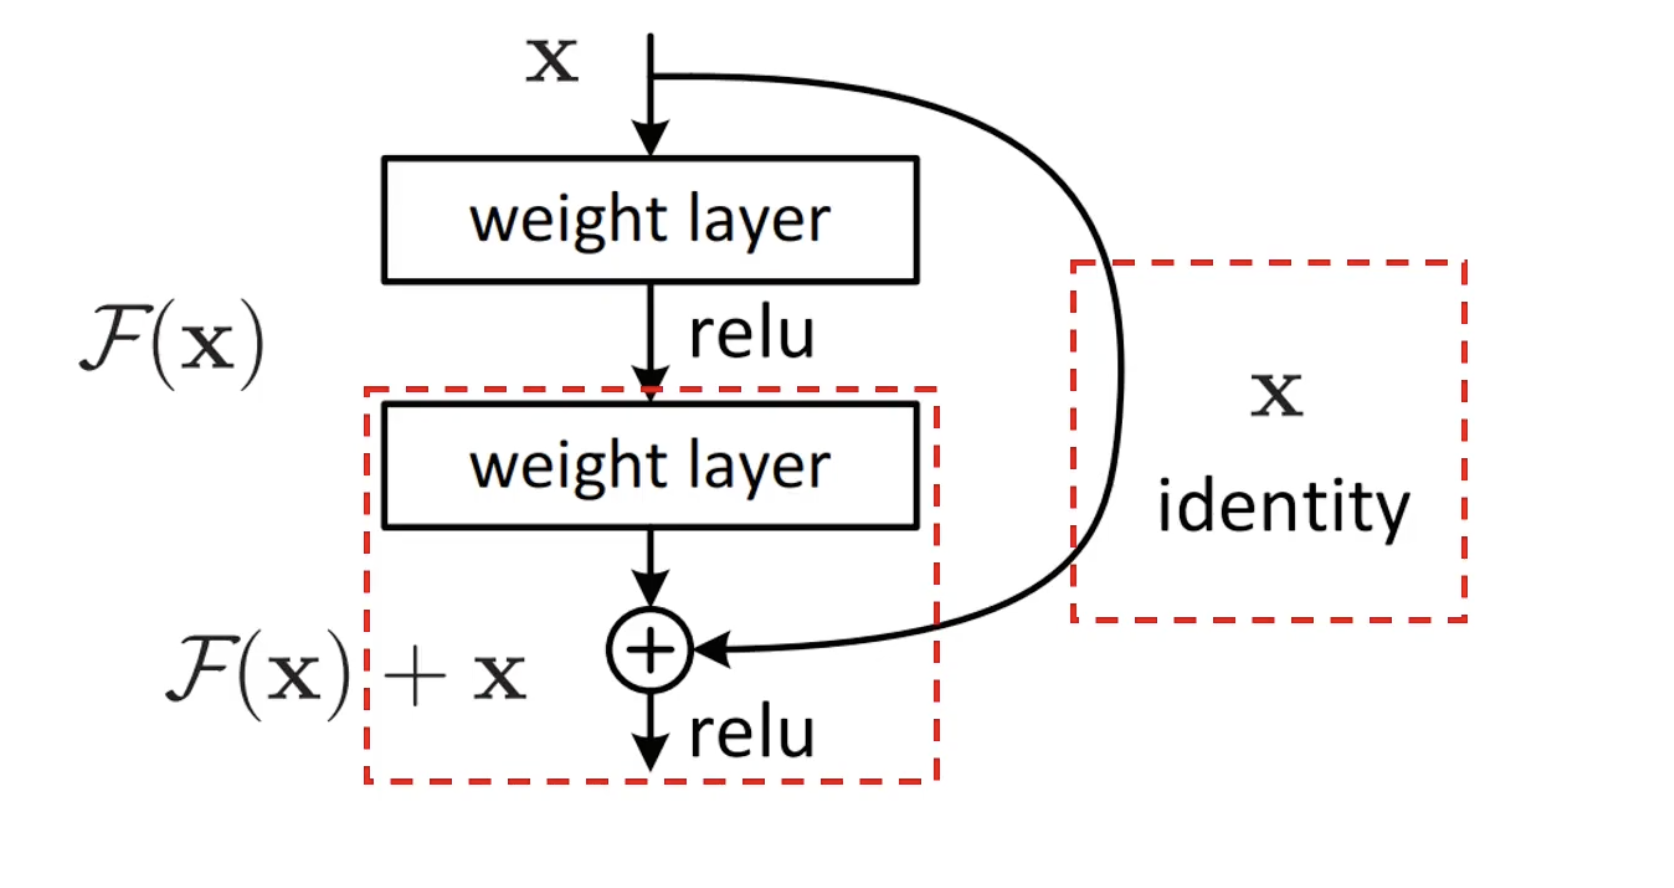

# MODEL Architecture

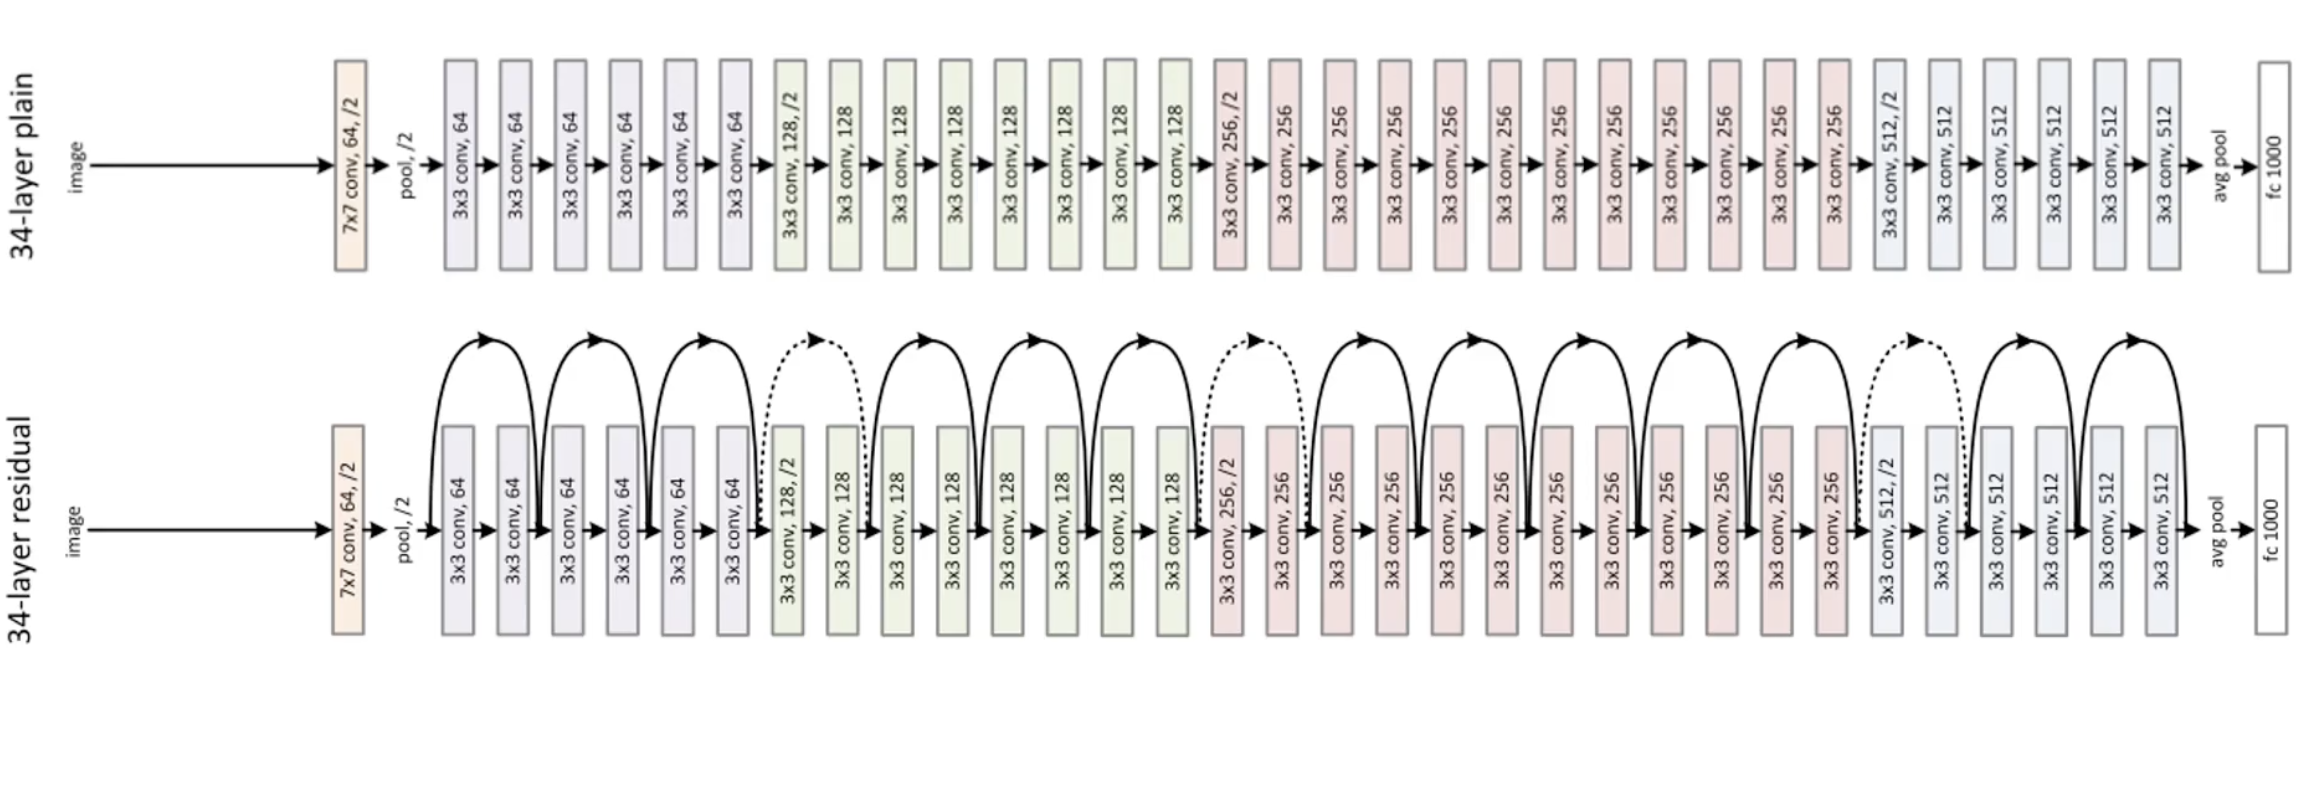

In [153]:
import torch
import torch.nn as nn
from torchvision import datasets
from torch.optim import AdamW
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from torchvision import transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.transforms import  ToTensor, Compose
from time import time
import matplotlib.pyplot as plt
import seaborn as sns
from ptflops import get_model_complexity_info

In [154]:
from torchvision.models import(resnet34, ResNet34_Weights)

model= resnet34(weights= ResNet34_Weights.DEFAULT)

In [155]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [156]:
model.fc
#fully connected layer

Linear(in_features=512, out_features=1000, bias=True)

## replacing the classifier head


### classifier had 1000 outs but we want only 2

In [157]:
model.fc=nn.Linear(model.fc.in_features,1)

In [158]:
device=torch.device('cuda')

In [159]:
model=model.to(device)

# Dataset Configure and Normalize and Dataloader

In [166]:
data_dir="/kaggle/input/datasets/parth04pt/cat-dog-images/data"

In [167]:
dataset= ImageFolder(root=data_dir)

In [161]:
gen = torch.Generator().manual_seed(42)

In [169]:
train_size= int(0.8* len(dataset))
test_size= len(dataset) - train_size

train_subset, test_subset= random_split(dataset, [train_size, test_size], generator=gen)

## DATA AUGMENTATION FOR FINE TUNING

In [170]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [171]:
test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [172]:
train_dataset = torch.utils.data.Subset(
    ImageFolder(
        root=data_dir,
        transform=train_transform
    ),
    train_subset.indices
)

test_dataset = torch.utils.data.Subset(
    ImageFolder(
        root=data_dir,
        transform=test_transform
    ),
    test_subset.indices
)

In [173]:
train_loader=DataLoader(train_dataset , batch_size=64, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=64, shuffle=False )

## freeze the back bone and unfreeze the head

In [174]:
# all freezed
for p in model.parameters():
    p.requires_grad=False

#head unfreezed
for p in model.fc.parameters():
    p.requires_grad= True

In [175]:
loss= nn.BCEWithLogitsLoss()
optim=torch.optim.AdamW(model.fc.parameters(),lr=1e-3)

In [176]:
classifer_epochs=5

# TRAINING THE CLASSIFIER HEAD TO UNDERSTAND DOG VS CAT

In [177]:
start = time()

for epoch in tqdm(range(classifer_epochs)):

    model.train()

    total = 0
    correct = 0
    epoch_loss = 0.0

    for imgs, labels in train_loader:

        imgs = imgs.to(device)

        labels = (
            labels.float()
            .unsqueeze(1)
            .to(device)
        )

        logits = model(imgs)

        l = loss(
            logits,
            labels
        )

        optim.zero_grad()

        l.backward()

        optim.step()

        probs = torch.sigmoid(logits)

        preds = (
            probs > 0.5
        ).float()

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        epoch_loss += l.item()

    print(
        f"Loss Epoch {epoch+1}: "
        f"{epoch_loss/len(train_loader):.4f}"
    )

    print(
        f"Accuracy Epoch {epoch+1}: "
        f"{100*correct/total:.2f}%"
    )

train_time = time() - start

  0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 20%|██        | 1/5 [01:58<07:54, 118.63s/it]

Loss Epoch 1: 0.1643
Accuracy Epoch 1: 94.66%


 40%|████      | 2/5 [03:56<05:54, 118.20s/it]

Loss Epoch 2: 0.0789
Accuracy Epoch 2: 97.32%


 60%|██████    | 3/5 [05:55<03:57, 118.54s/it]

Loss Epoch 3: 0.0708
Accuracy Epoch 3: 97.29%


 80%|████████  | 4/5 [07:55<01:58, 118.96s/it]

Loss Epoch 4: 0.0625
Accuracy Epoch 4: 97.69%


100%|██████████| 5/5 [09:53<00:00, 118.70s/it]

Loss Epoch 5: 0.0618
Accuracy Epoch 5: 97.63%


# Unfreeze the entire Network

In [178]:
for p in model.parameters():
    p.requires_grad= True

### new optimizeer for next training and schedular

In [179]:
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-5,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=10)

# FINE TUNING TRAINING LOOP

In [180]:
FT_EPOCHS=10

In [181]:
start = time()

for epoch in tqdm(range(FT_EPOCHS)):

    model.train()

    total = 0
    correct = 0
    epoch_loss = 0.0

    for imgs, labels in train_loader:

        imgs = imgs.to(device)

        labels = (
            labels.float()
            .unsqueeze(1)
            .to(device)
        )

        logits = model(imgs)

        l = loss(
            logits,
            labels
        )

        optim.zero_grad()

        l.backward()

        optim.step()

        probs = torch.sigmoid(logits)

        preds = (
            probs > 0.5
        ).float()

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        epoch_loss += l.item()

    print(
        f"Loss Epoch {epoch+1}: "
        f"{epoch_loss/len(train_loader):.4f}"
    )

    print(
        f"Accuracy Epoch {epoch+1}: "
        f"{100*correct/total:.2f}%"
    )

train_time = time() - start

 10%|█         | 1/10 [03:03<27:33, 183.78s/it]

Loss Epoch 1: 0.0606
Accuracy Epoch 1: 97.67%


 20%|██        | 2/10 [06:06<24:25, 183.23s/it]

Loss Epoch 2: 0.0610
Accuracy Epoch 2: 97.64%


 30%|███       | 3/10 [09:08<21:17, 182.49s/it]

...

Loss Epoch 8: 0.0513
Accuracy Epoch 8: 98.06%


 90%|█████████ | 9/10 [27:29<03:04, 184.25s/it]

Loss Epoch 9: 0.0510
Accuracy Epoch 9: 98.09%


100%|██████████| 10/10 [30:33<00:00, 183.33s/it]

Loss Epoch 10: 0.0493
Accuracy Epoch 10: 98.08%


## TESTING

In [182]:
model.eval()

correct = 0
total = 0

LOSS = 0.0

all_preds = []
all_labels = []

start = time()

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        labels = (
            labels.float()
            .unsqueeze(1)
            .to(device)
        )

        logits = model(imgs)

        l = loss(
            logits,
            labels
        )

        probs = torch.sigmoid(logits)

        preds = (
            probs > 0.5
        ).float()

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        LOSS += l.item()

        all_preds.extend(
            preds.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.cpu().numpy().flatten()
        )

test_time = time() - start

print(
    f"Test Loss : "
    f"{LOSS/len(test_loader):.4f}"
)

print(
    f"Test Accuracy : "
    f"{100*correct/total:.2f}%"
)

print(
    f"Test Time : "
    f"{test_time:.2f}s"
)

Test Loss : 0.0430
Test Accuracy : 98.58%
Test Time : 33.44s


## custom inference
#### file path -> pil image -> tensor -> unsqueeze(0) -> pass to model

In [183]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [213]:
from PIL import Image
model.eval()
dog = Image.open("/kaggle/input/datasets/parth04pt/cat-dog-infer/dog.jpeg").convert("RGB")
cat=Image.open("/kaggle/input/datasets/parth04pt/cat-image/cat.png").convert("RGB")

In [185]:
infer_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [186]:
dog_tensor = infer_transform(dog)

cat_tensor = infer_transform(cat)

In [187]:
start= time()
logit1 = model(dog_tensor.unsqueeze(0).to(device))
prob1 = torch.sigmoid(logit1)
prediction1 = int(prob1 > 0.5)
infer_time1 = time()- start

In [188]:
confidence1 = prob1.item()

In [189]:
cls=["cat", "dog"]

In [190]:
mean=[0.485,0.456,0.406]
std_dev=[0.229,0.224,0.225]

In [191]:
mean=torch.tensor(mean)
std_dev=torch.tensor(std_dev)

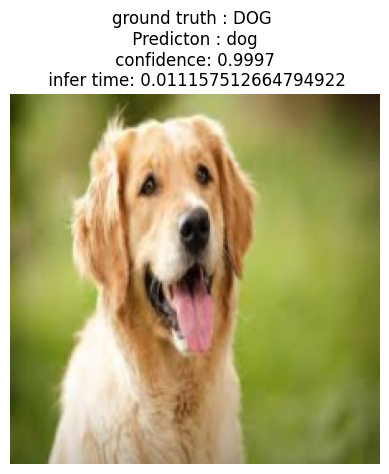

In [192]:
plt.title(f"ground truth : DOG \n Predicton : {cls[prediction1]} \n confidence: {confidence1:.4f} \n infer time: {infer_time1}")
img= dog_tensor.squeeze(0).cpu()
img = img * std_dev.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

In [221]:
start= time()
logit2 = model(cat_tensor.unsqueeze(0).to(device))
prob2 = torch.sigmoid(logit2)
prediction2 = int(prob2 > 0.5)
infer_time2 = time()- start

In [222]:
logit2

tensor([[-11.5815]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [228]:
confidence2 = 1-prob2.item()

In [229]:
confidence2

0.9999906624125288

In [230]:
prediction2

0

In [231]:
dataset.classes

['Cat', 'Dog']

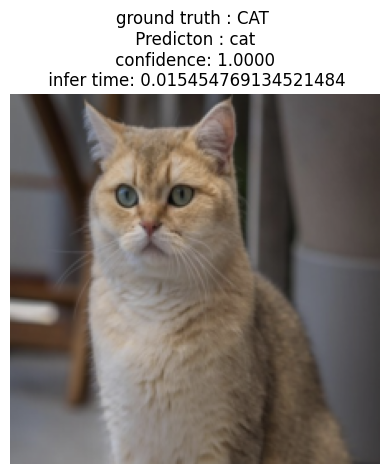

In [232]:
plt.title(f"ground truth : CAT \n Predicton : {cls[prediction2]} \n confidence: {confidence2:.4f} \n infer time: {infer_time2}")
img= cat_tensor.squeeze(0).cpu()
img = img * std_dev.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

# METRICS

In [233]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc= accuracy_score(all_labels, all_preds)
pre = precision_score(all_labels, all_preds),
rec= recall_score(all_labels, all_preds)
f1= f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

In [234]:
num_paramerters=0
num_layers=0
for p in model.parameters():
    num_layers+=1
    num_paramerters+=p.numel()
    #weights
    #bias

In [241]:
trainable_parameters = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

In [235]:
memory_usage= torch.torch.cuda.memory_allocated()/1024**2

In [236]:
macs, params = get_model_complexity_info(model,(3,224,224),as_strings=False,print_per_layer_stat=False)

In [237]:
flops= macs*2

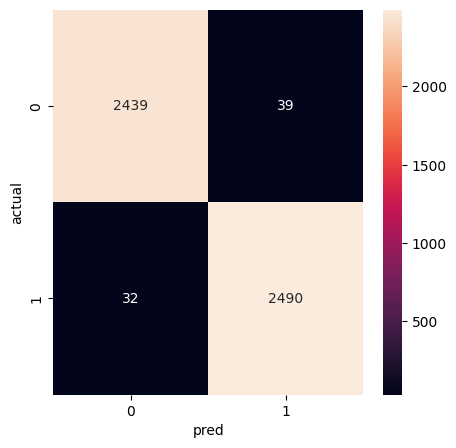

In [238]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt= 'd')
plt.xlabel("pred")
plt.ylabel("actual")
plt.show()

In [242]:
print("="*60)
print("RESNET34 TRANSFER LEARNING RESULTS")
print("="*60)

print(f"Model                : ResNet34")
print(f"Classifier Epochs    : {classifer_epochs}")
print(f"Fine-Tuning Epochs   : {FT_EPOCHS}")

print()

print(f"Accuracy             : {acc:.4f}")
print(f"Precision            : {pre[0]:.4f}")
print(f"Recall               : {rec:.4f}")
print(f"F1 Score             : {f1:.4f}")

print()

print(f"Training Time        : {train_time:.2f}s")
print(f"Testing Time         : {test_time:.2f}s")

print()

print(f"Parameters           : {num_paramerters:,}")
print(f"Trainable Parameters : {trainable_parameters:,}")
print(f"Layers               : {num_layers:,}")

print()

print(f"FLOPs                : {flops:,.0f}")
print(f"Memory Usage         : {memory_usage:.2f} MB")

print()

print("Classes              :", cls)

print()

print("Confusion Matrix")
print(cm)

print("="*60)

RESNET34 TRANSFER LEARNING RESULTS
Model                : ResNet34
Classifier Epochs    : 5
Fine-Tuning Epochs   : 10

Accuracy             : 0.9858
Precision            : 0.9846
Recall               : 0.9873
F1 Score             : 0.9859

Training Time        : 1833.28s
Testing Time         : 33.44s

Parameters           : 21,285,185
Trainable Parameters : 21,285,185
Layers               : 110

FLOPs                : 7,359,013,890
Memory Usage         : 567.17 MB

Classes              : ['cat', 'dog']

Confusion Matrix
[[2439   39]
 [  32 2490]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=cls
    )
)

              precision    recall  f1-score   support

         cat       0.99      0.98      0.99      2478
         dog       0.98      0.99      0.99      2522

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000

